# Week 5: Reshaping Data & Python Files

This notebook has **two parts**:

1. **Part 1 – Reshaping in a notebook**: Learn why data comes in different shapes and how to use `pivot()` to change it.
2. **Part 2 – Python files**: See how we can put that exact same logic into `.py` files and call it from the notebook.

---

## Why does data shape matter?

Data can be stored in two common shapes:

| Shape | What it looks like | Example |
|-------|--------------------|---------|
| **Long** | One row per observation (country + year + variable) | Each row is one economic indicator for one country in one year |
| **Wide** | One row per entity, each variable gets its own column | Each row is one country-year, with GDP, inflation, unemployment as separate columns |

Both shapes are useful. Long is great for storing and filtering; wide is great for analysis and visualization.

`pivot()` converts **long → wide**.

---
# Part 1: Reshaping Data in the Notebook

## 1.1 Load the data

We will use the **IMF World Economic Outlook** dataset.
It is stored in **long format**: each row is one country, one year, and one economic variable.

In [1]:
import pandas as pd

In [2]:
data_path = "../../data/examples/week_5/imf_weo_countries.parquet"
df_raw = pd.read_parquet(data_path)
df_raw.head(2)

,weo_country_code,iso,weo_subject_code,country,subject_descriptor,subject_notes,units,scale,country_series-specific_notes,estimates_start_after,unnamed:_60,year,value
0,512,AFG,NGDP_R,Afghanistan,"Gross domestic product, constant prices",Expressed in billions of national currency uni...,National currency,Billions,Source: National Statistics Office Latest actu...,2024,NaN,1980,NaN
1,512,AFG,NGDP_RPCH,Afghanistan,"Gross domestic product, constant prices",Annual percentages of constant price GDP are y...,Percent change,Units,"See notes for: Gross domestic product, consta...",2024,NaN,1980,NaN


The raw dataset has many columns. Let's look at the unique **subject codes** — these are the different economic variables stored in each row.

In [3]:
df_raw['weo_subject_code'].unique()[:10]

<ArrowStringArray>
[    'NGDP_R',  'NGDP_RPCH',       'NGDP',      'NGDPD',     'PPPGDP',
     'NGDP_D',    'NGDPRPC', 'NGDPRPPPPC',     'NGDPPC',    'NGDPDPC']
Length: 10, dtype: str

## 1.2 Clean: keep only the columns and variables we need

We will focus on three variables:
- `NGDP_RPCH` — GDP growth rate (%)
- `LUR` — Unemployment rate (%)
- `PCPIPCH` — Inflation rate (%)

In [4]:


# Keep only the columns we need
df = df_raw[["iso", "year", "weo_subject_code", "value"]]

# Keep only the three subject codes
codes_to_keep = ["NGDP_RPCH", "LUR", "PCPIPCH"]
df = df[df["weo_subject_code"].isin(codes_to_keep)]

# Drop rows with missing values
df = df.dropna(subset=["value"])

# Convert year to integer
df["year"] = df["year"].astype(int)

df.head(6)

,iso,year,weo_subject_code,value
45,ALB,1980,NGDP_RPCH,2.684
68,ALB,1980,LUR,5.028
89,DZA,1980,NGDP_RPCH,-5.400
105,DZA,1980,PCPIPCH,9.668
112,DZA,1980,LUR,15.789
177,AGO,1980,NGDP_RPCH,2.406


**This is the long format.** Each row is a unique combination of `(country, year, variable)`. Notice that for the same country and year there are multiple rows — one for each economic variable.

In [5]:
# Example: Japan in 2020 -- three rows, one per variable
df.query("iso == 'JPN' and year == 2020")

,iso,year,weo_subject_code,value
348741,JPN,2020,NGDP_RPCH,-4.168
348757,JPN,2020,PCPIPCH,-0.027
348764,JPN,2020,LUR,2.800


## 1.3 Reshape: `pivot()` from long to wide

`pivot()` takes three arguments:

| Argument | Meaning |
|----------|---------|
| `index`  | The column(s) that identify each unique row in the output |
| `columns` | The column whose values become new column headers |
| `values` | The column whose values fill the new wide table |

We want:
- `index` = `["iso", "year"]` — one row per country-year
- `columns` = `"weo_subject_code"` — each code becomes a column
- `values` = `"value"` — the numbers fill the table

In [6]:
df_wide = df.pivot(index=["iso", "year"], columns="weo_subject_code", values="value")
df_wide = df_wide.reset_index()
df_wide.columns.name = None  # Remove the label 'weo_subject_code' from the column axis
df_wide.head(5)

,iso,year,LUR,NGDP_RPCH,PCPIPCH
0,ABW,1987,NaN,16.079,3.639
1,ABW,1988,NaN,18.640,3.121
2,ABW,1989,NaN,12.095,3.989
3,ABW,1990,NaN,3.977,5.838
4,ABW,1991,6.078,7.975,5.553


**This is the wide format.** Each row is now one country-year, and each economic variable has its own column.

Let's verify: Japan in 2020 is now just ONE row.

In [7]:
df_wide.query("iso == 'JPN' and year == 2020")

,iso,year,LUR,NGDP_RPCH,PCPIPCH
4151,JPN,2020,2.8,-4.168,-0.027


## 1.4 Rename columns to something readable

The column names are still the IMF codes. Let's rename them.

In [8]:
rename_map = {
    "NGDP_RPCH": "gdp_growth",
    "LUR": "unemployment",
    "PCPIPCH": "inflation",
}
df_wide = df_wide.rename(columns=rename_map)
df_wide.head(5)

,iso,year,unemployment,gdp_growth,inflation
0,ABW,1987,NaN,16.079,3.639
1,ABW,1988,NaN,18.640,3.121
2,ABW,1989,NaN,12.095,3.989
3,ABW,1990,NaN,3.977,5.838
4,ABW,1991,6.078,7.975,5.553


## 1.5 Quick visualization to confirm the data makes sense

Now that the data is in wide format, it is easy to plot one variable against another — for example, GDP growth over time for Japan.

array([<Axes: xlabel='year'>, <Axes: xlabel='year'>,
       <Axes: xlabel='year'>], dtype=object)

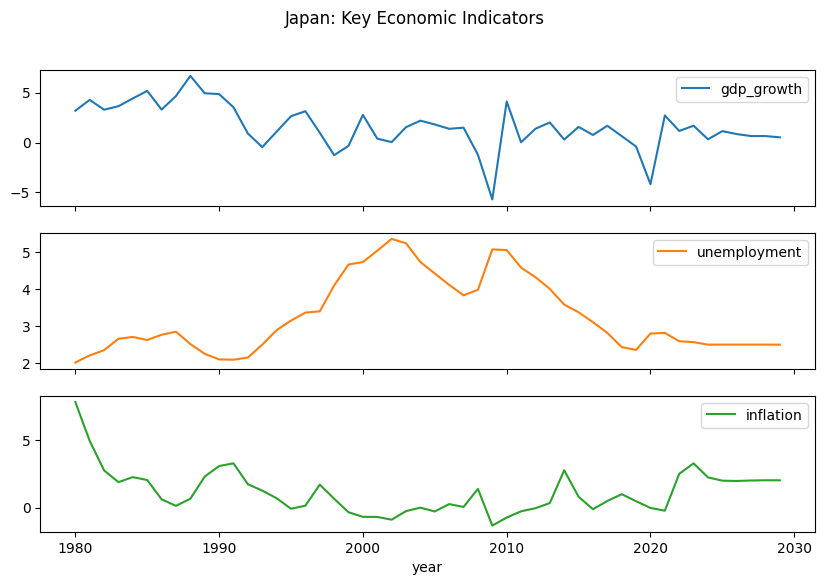

In [9]:
df_jpn = df_wide.query("iso == 'JPN'").set_index("year")
df_jpn[["gdp_growth", "unemployment", "inflation"]].dropna().plot(
    subplots=True, figsize=(10, 6), title="Japan: Key Economic Indicators"
)

---
# Part 2: Moving Code into Python Files

Everything we just did in Part 1 is great — but notebooks have a problem: **the code only lives in the notebook**.

If another notebook, or a colleague, wants to do the same import + pivot, they have to copy-paste all that code. That leads to bugs, duplication, and maintenance headaches.

**The solution: put reusable logic in `.py` files.**

We have already created two files for you:

```
src/
└── data/
    ├── data_import.py     ← load_imf_data() function  (loads + cleans the long data)
    └── data_manipulate.py ← pivot_to_wide() function  (pivots long → wide)
```

Each file contains a **plain Python function**. Let's look at what they contain, then use them.

## 2.1 `load_imf_data` — loading and cleaning the raw data

This is **exactly** what we did manually in Part 1, now in a seperate file

## 2.2 `pivot_to_wide` — the pivot

Open `src/data/data_manipulate.py` and you will see:

```python
import pandas as pd

# Maps the raw IMF subject codes to human-readable column names
RENAME_MAP = {
    "NGDP_RPCH": "gdp_growth",
    "LUR": "unemployment",
    "PCPIPCH": "inflation",
}


def pivot_to_wide(df):
    # pivot() reshapes the data from long format to wide format:
    #   index   = the columns that identify each unique row in the output
    #   columns = the column whose values become new column headers
    #   values  = the column whose numbers fill the table
    df_wide = df.pivot(index=["iso", "year"], columns="weo_subject_code", values="value")
    # Move iso and year back from the index into regular columns
    df_wide = df_wide.reset_index()
    # Remove the axis label "weo_subject_code" that pivot() adds automatically
    df_wide.columns.name = None
    # Rename the IMF codes to plain English
    df_wide = df_wide.rename(columns=RENAME_MAP)
    return df_wide
```

Again — exactly the pivot steps from Part 1, now in a plain function.

## 2.3 Import the functions and run them

We need to tell Python where to find our `src` folder. We do this by adding the project root to the path.

In [10]:
import sys
sys.path.insert(0, "../..")

In [11]:
from src.data.data_import import load_imf_data
from src.data.data_manipulate import pivot_to_wide

### Step 1: Load and clean the data

In [13]:
df_long = load_imf_data()

In [14]:
print("Shape (long):", df_long.shape) # This line prints the shape of the data

Shape (long): (22401, 4)


In [16]:
df_long.head(4)

,iso,year,weo_subject_code,value
45,ALB,1980,NGDP_RPCH,2.684
68,ALB,1980,LUR,5.028
89,DZA,1980,NGDP_RPCH,-5.400
105,DZA,1980,PCPIPCH,9.668


### Step 2: Pivot to wide format

In [18]:
df_wide_from_fn = pivot_to_wide(df_long)
df_wide_from_fn.head(2)

,iso,year,unemployment,gdp_growth,inflation
0,ABW,1987,NaN,16.079,3.639
1,ABW,1988,NaN,18.640,3.121


In [19]:
print("Shape (wide):", df_wide_from_fn.shape)
df_wide_from_fn.head(5)

Shape (wide): (8979, 5)


,iso,year,unemployment,gdp_growth,inflation
0,ABW,1987,NaN,16.079,3.639
1,ABW,1988,NaN,18.640,3.121
2,ABW,1989,NaN,12.095,3.989
3,ABW,1990,NaN,3.977,5.838
4,ABW,1991,6.078,7.975,5.553


**The result is identical to what we produced in Part 1** — but now the logic lives in reusable `.py` files.

Any other notebook (or script) in the project can do:

```python
from src.data.data_import import load_imf_data
from src.data.data_manipulate import pivot_to_wide

df_long = load_imf_data()
df_wide = pivot_to_wide(df_long)
```

No copy-pasting. No duplication.

## 2.4 Same visualization — same result

Let's reproduce the Japan chart from Part 1 using the function output to confirm everything matches.

array([<Axes: xlabel='year'>, <Axes: xlabel='year'>,
       <Axes: xlabel='year'>], dtype=object)

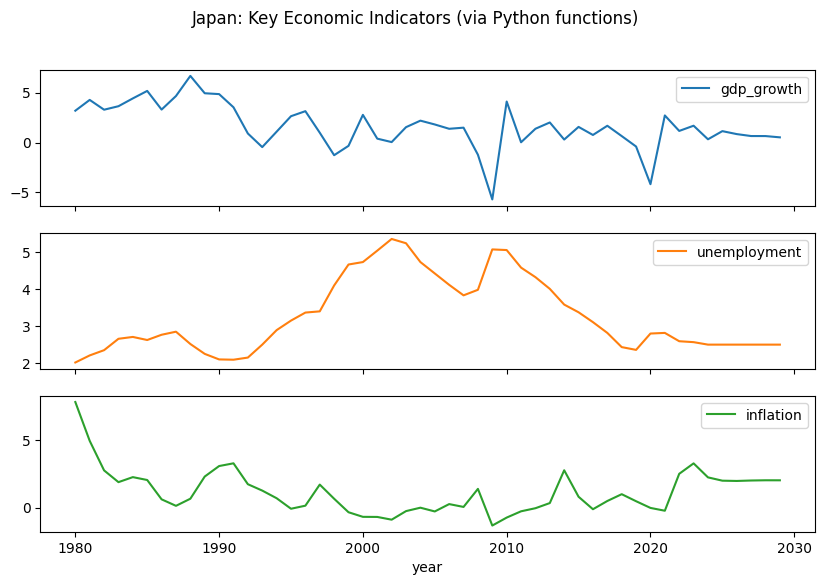

In [20]:
df_jpn2 = df_wide_from_fn.query("iso == 'JPN'").set_index("year")
df_jpn2[["gdp_growth", "unemployment", "inflation"]].dropna().plot(
    subplots=True, figsize=(10, 6), title="Japan: Key Economic Indicators (via Python functions)"
)

---
## Summary

| | Part 1 (notebook) | Part 2 (Python files) |
|---|---|---|
| Where is the code? | Inside the notebook | In `src/data/*.py` |
| Can other notebooks reuse it? | No (copy-paste required) | **Yes** — just import |
| Easy to test? | Manual | Can write unit tests |
| Result | Same wide DataFrame | Same wide DataFrame |

**Key takeaway**: Notebooks are great for exploration. Python files are great for logic you want to reuse. In professional data science work, you do both — explore in notebooks, then move the logic to `.py` files.